# Персептрон

In [1]:
import random
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.lines import Line2D
from IPython.display import display, Image

## Датасет

Два признака (x₁, x₂) и два класса: **0** — не принят (красный), **1** — принят (синий).  
Класс определяется по сумме баллов за два экзамена: если оба экзамена сданы хорошо — студент принят.

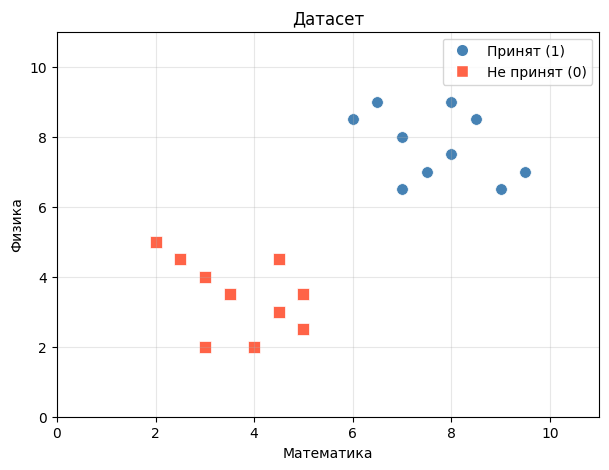

In [2]:
random.seed(7)

# x1 — балл за экзамен по математике, x2 — балл за экзамен по физике
# label: 1 — принят, 0 — не принят
data = [
    # принят (label=1): высокие баллы по обоим экзаменам
    (8.0, 7.5, 1), (7.0, 8.0, 1), (9.0, 6.5, 1), (6.5, 9.0, 1),
    (8.5, 8.5, 1), (7.5, 7.0, 1), (9.5, 7.0, 1), (6.0, 8.5, 1),
    (8.0, 9.0, 1), (7.0, 6.5, 1),
    # не принят (label=0): низкие баллы хотя бы по одному экзамену
    (3.0, 4.0, 0), (4.5, 3.0, 0), (2.0, 5.0, 0), (5.0, 2.5, 0),
    (3.5, 3.5, 0), (4.0, 2.0, 0), (2.5, 4.5, 0), (5.0, 3.5, 0),
    (3.0, 2.0, 0), (4.5, 4.5, 0),
]

features = [(x1, x2) for x1, x2, _ in data]
labels   = [label for _, _, label in data]

plt.figure(figsize=(7, 5))
for (x1, x2), label in zip(features, labels):
    color  = 'steelblue' if label == 1 else 'tomato'
    marker = 'o'         if label == 1 else 's'
    plt.scatter(x1, x2, color=color, marker=marker, s=70, edgecolors='white', linewidths=0.5)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Принят (1)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='tomato',    markersize=9, label='Не принят (0)'),
]
plt.legend(handles=legend_elements)
plt.xlabel('Математика')
plt.ylabel('Физика')
plt.title('Датасет')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid(True, alpha=0.3)
plt.show()

## Вспомогательные функции

In [3]:
def save_gif(history, path='assets/perceptron.gif', interval=300, step=1):
    """
    Сохраняет анимацию движения границы решения в GIF и выводит её в ноутбуке.

    history — список троек (w1, w2, b), по одной на итерацию обучения.
              Граница решения: w1*x1 + w2*x2 + b = 0
              Отсюда: x2 = -(w1*x1 + b) / w2
    step    — брать каждый N-й кадр.
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    frames = history[::step]

    fig, ax = plt.subplots(figsize=(7, 5))

    def draw_frame(i):
        w1, w2, b = frames[i]
        ax.clear()

        # Точки датасета
        for (x1, x2), label in zip(features, labels):
            color  = 'steelblue' if label == 1 else 'tomato'
            marker = 'o'         if label == 1 else 's'
            ax.scatter(x1, x2, color=color, marker=marker, s=70,
                       edgecolors='white', linewidths=0.5)

        # Граница решения: x2 = -(w1*x1 + b) / w2
        x1_vals = [0, 11]
        if abs(w2) > 1e-9:
            x2_vals = [-(w1 * x + b) / w2 for x in x1_vals]
            ax.plot(x1_vals, x2_vals, color='purple', linewidth=2,
                    label=f'w1={w1:.2f}  w2={w2:.2f}  b={b:.2f}')
        else:
            # Вертикальная линия при w2 ≈ 0
            if abs(w1) > 1e-9:
                x_vert = -b / w1
                ax.axvline(x_vert, color='purple', linewidth=2,
                           label=f'w1={w1:.2f}  w2={w2:.2f}  b={b:.2f}')

        ax.set_xlim(0, 11)
        ax.set_ylim(0, 11)
        ax.set_xlabel('Математика')
        ax.set_ylabel('Физика')
        ax.set_title(f'Итерация {i * step + 1}/{len(history)}')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

    anim = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=interval)
    anim.save(path, writer='pillow')
    plt.close(fig)
    print(f'GIF сохранён: {path}  ({len(frames)} кадров из {len(history)})')
    display(Image(filename=path))

In [4]:
def plot_errors(histories, labels_list, title='Ошибка по эпохам', ylabel='Ошибка'):
    """
    Рисует график ошибки по эпохам для одного или нескольких методов.

    histories   — список списков ошибок, по одному на метод.
    labels_list — список названий методов.
    """
    plt.figure(figsize=(9, 4))
    for history, label in zip(histories, labels_list):
        plt.plot(history, linewidth=1.5, label=label)
    plt.xlabel('Эпоха')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Персептрон (нейрон)

Формула персептрона такая же, как у линейной регрессии: `y = w1*x1 + ... + wn*xn + b`, где `w` — веса признаков, `b` — смещение. Но **задача другая**: не предсказать число, а отнести точку к одному из двух классов.

Геометрически: линейная регрессия проводит прямую *как можно ближе* к каждой точке, а персептрон проводит прямую так, чтобы она *разделяла* две группы точек.

---

### Два вида ошибок

Прямая делит пространство на две зоны — положительную (`1`) и отрицательную (`0`). Ошибка возникает в двух случаях:

- `y=1`, `y_pred=0` — точка из положительной зоны попала в отрицательную
- `y=0`, `y_pred=1` — точка из отрицательной зоны попала в положительную

Если `y == y_pred` — прямую двигать не нужно.

---

### Функция ошибки

Можно было бы считать просто количество неверно классифицированных точек, но это целое число, которое меняется скачками — градиентный спуск с ним работает плохо. Можно было бы использовать расстояние от точки до прямой, но это вычислительно дорого (формула Пифагора).

Поэтому используется **значение формулы модели** `w1*x1 + w2*x2 + b`: оно коррелирует с расстоянием от точки до прямой — маленькое, когда точка близко, большое, когда далеко. И знак у него правильный: положительное — точка в зоне `1`, отрицательное — в зоне `0`.

---

### Обновление весов (градиентный спуск)

Производная функции ошибки даёт правило обновления:

```
w += learning_rate * (y - y_pred) * x
b += learning_rate * (y - y_pred)
```

- `(y - y_pred)` — определяет **направление** сдвига (`+1` или `-1`)
- `learning_rate` — определяет **размер** шага
- `x` — масштабирует шаг пропорционально значению признака (математически это производная)

Веса обновляются **только при ошибке**: если `y == y_pred`, градиент равен нулю и прямая не двигается.

---

### Функция активации (step)

Формула модели выдаёт произвольное число. Чтобы получить класс `0` или `1`, применяется ступенчатая функция:

```
step(value) = 1, если value >= 0
step(value) = 0, если value < 0
```

---

### Алгоритм обучения

1. Инициализировать `w1, w2, b`
2. На каждой эпохе:
   - Взять случайную точку
   - Вычислить `value = model(x1, x2)` и `y_pred = step(value)`
   - Если `y != y_pred` — обновить веса через градиентный спуск
3. Повторить

---

### Интерпретация весов

По знаку и величине весов можно понять, какие признаки важны для каждого класса: большой положительный `w` — признак характерен для класса `1`, большой отрицательный — для класса `0`.

In [5]:
random.seed(42)
epochs = 1000
learning_rate = 0.01

w1, w2, b = 1.0, 1.0, 0.0

# Формула персептрона: линейная комбинация признаков
model = lambda x1, x2, w1, w2, b: w1 * x1 + w2 * x2 + b

# Функция активации (ступенчатая): превращает число в класс 0 или 1
step = lambda value: 1 if value >= 0 else 0

def avg_error(w1, w2, b):
    """Средняя ошибка по всем точкам: |model| если ошибка, иначе 0."""
    errors = [
        abs(model(x1, x2, w1, w2, b)) if y != step(model(x1, x2, w1, w2, b)) else 0
        for x1, x2, y in data
    ]
    return sum(errors) / len(data)

params_history = []
error_history  = [avg_error(w1, w2, b)]  # начальная ошибка до обучения

# Градиентный спуск (SGD): обновляем веса только при ошибке классификации.
# Производная функции ошибки:
#   ∂/∂w1 = (y - y_pred) * x1
#   ∂/∂w2 = (y - y_pred) * x2
#   ∂/∂b  = (y - y_pred)
# Знак (y - y_pred) определяет направление сдвига, x — его масштаб.
for epoch in range(epochs):
    params_history.append((w1, w2, b))

    x1, x2, y = data[random.randint(0, len(data) - 1)]
    y_pred = step(model(x1, x2, w1, w2, b))

    if y != y_pred:
        w1 += learning_rate * (y - y_pred) * x1
        w2 += learning_rate * (y - y_pred) * x2
        b  += learning_rate * (y - y_pred)

    error_history.append(avg_error(w1, w2, b))

    if epoch % 100 == 0:
        print(f"{epoch=} avg_error={error_history[-1]:.3f}")

epoch=0 avg_error=3.575
epoch=100 avg_error=0.002
epoch=200 avg_error=0.000
epoch=300 avg_error=0.000
epoch=400 avg_error=0.000
epoch=500 avg_error=0.000
epoch=600 avg_error=0.000
epoch=700 avg_error=0.000
epoch=800 avg_error=0.000
epoch=900 avg_error=0.000


GIF сохранён: assets/perceptron.gif  (67 кадров из 1000)


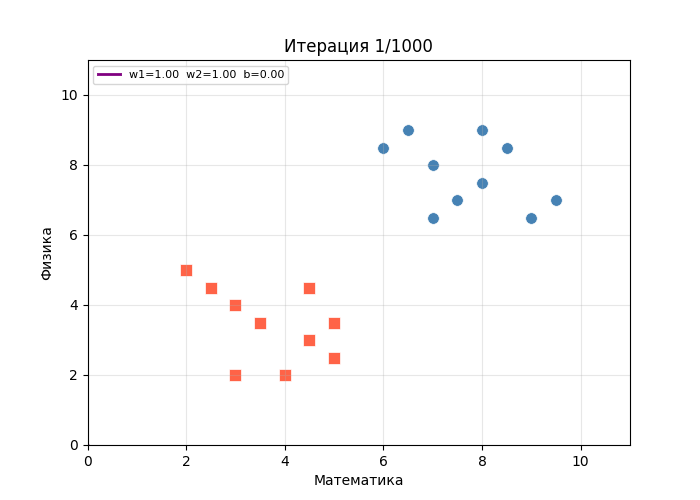

In [6]:
save_gif(params_history, path='assets/perceptron.gif', interval=300, step=15)

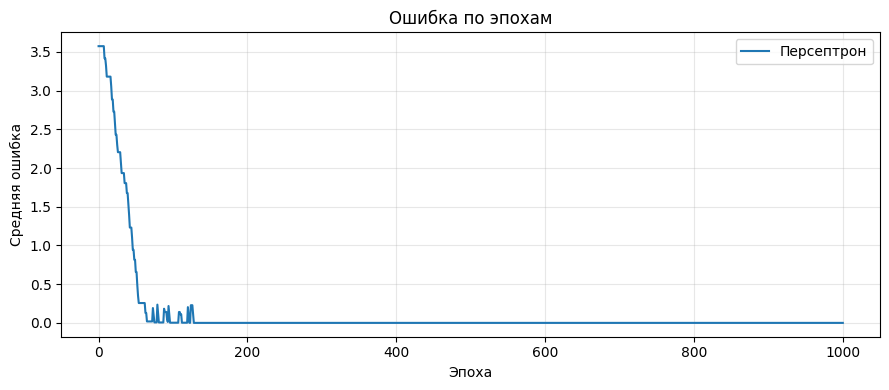

In [7]:
plot_errors([error_history], ['Персептрон'], ylabel='Средняя ошибка')